In [13]:
import numpy as np
def newton(F, J, x, tol):
    x = np.array(x, dtype=np.float64)
    norm = np.linalg.norm(F(x), axis=0) # Norm across the component dimension
    
    # Continue while any point in the grid has not converged
    while np.any(norm > tol):
        # Solve J * delta = -F at every grid point
        # np.linalg.solve expects (..., M, M) and (..., M)
        # We transpose to align the system correctly for the meshgrid
        delta = np.linalg.solve(J(x).T, -F(x).T).T
        x += delta
        norm = np.linalg.norm(F(x), axis=0)
        
    return x

def F(X):
    (x, y) = X
    return np.array([x**2 - y - 1, x - y**2 + 1])
def J(X):
    (x, y) = X
    return np.array([[2*x, -1], [1, -2*y]])


X, Y = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-2, 2, 100))
Z = newton(F, J, [X, Y], tol=1e-8)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 2) + inhomogeneous part.

In [45]:
import numpy as np
import matplotlib.pyplot as plt

def newton_fractal(F, J, x_grid, y_grid, tol=1e-8, max_iter=40):
    X, Y = np.meshgrid(x_grid, y_grid)
    points = np.stack([X, Y], axis=0)
    orig_shape = X.shape
    
    # Flatten to (2, N) for simpler processing
    x = points.reshape(2, -1)
    
    for _ in range(max_iter):
        f_val = F(x)
        norm = np.linalg.norm(f_val, axis=0)
        active = norm > tol
        if not np.any(active): break
            
        x_act = x[:, active]
        # J(x_act) returns shape (2, 2, n_active)
        # We need (n_active, 2, 2) for linalg.solve
        jac = J(x_act).transpose(2, 0, 1)
        f_act = -f_val[:, active].T
        
        delta = np.linalg.solve(jac, f_act)
        x[:, active] += delta.T

    # Identify the 4 roots to colour the fractal
    final_points = x.T
    root_map = np.full(final_points.shape[0], -1, dtype=int)
    unique_roots = []

    for i, p in enumerate(final_points):
        # Handle points that didn't converge
        if np.any(np.isnan(p)): continue
        
        found = False
        for r_idx, r_val in enumerate(unique_roots):
            if np.linalg.norm(p - r_val) < 1e-3:
                root_map[i] = r_idx
                found = True
                break
        if not found and len(unique_roots) < 4:
            root_map[i] = len(unique_roots)
            unique_roots.append(p)
            
    return root_map.reshape(orig_shape)

def F(X):
    x, y = X
    return np.array([x**2 - y - 1, x - y**2 + 1])

def J(X):
    x, y = X
    ones = np.ones_like(x)
    return np.array([[2*x, -ones], [ones, -2*y]])

# Execution
x_range = np.linspace(-2, 2, 1000)
y_range = np.linspace(-2, 2, 1000)
fractal = newton_fractal(F, J, x_range, y_range)

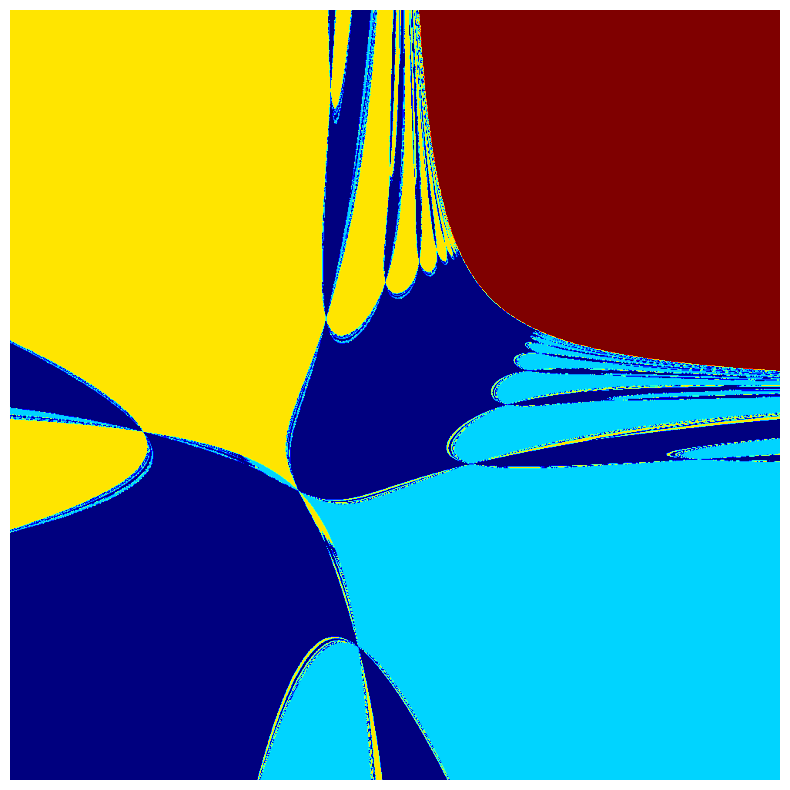

In [46]:
plt.figure(figsize=(10, 10))
plt.imshow(fractal, extent=[-2, 2, -2, 2], cmap='jet', origin='lower')
plt.axis('off')
plt.show()

In [44]:
class ResultObject:
    def __init__(self, x=None, y=None):
        self.x = x
        self.y = y

# assign during creation
def f(x, y):
    return ResultObject(x, y)

result = f(1, 2)
print(result.x, result.y)   # prints 1, 2

# assign after creation
def g(x, y):
    res = ResultObject()
    res.x = x
    res.y = y
    return res

result = g(2, 3)
print(result.x, result.y)   # prints 2, 3

SyntaxError: invalid non-printable character U+00A0 (1334431088.py, line 2)